In [3]:
# ============================================================
# Activation Patching: nsubj Agreement (English)
# 完整流程：Localization → Necessity → Circuit
# 修复点：
#   1. Ablation hook 统一到 attention.self（与 patching 一致）
#   2. Mean ablation 在 attention.self 输出空间按 head 维度计算
#   3. 样本过滤策略明确（delta > 0）
#   4. 解析函数统一命名和逻辑
# ============================================================

# ==========================
# Cell 1: 环境配置与模型加载
# ==========================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import itertools
from transformers import AutoModel, AutoTokenizer

sys.path.append("/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/src/")
from train_parser import BiaffineDependencyParser, mask_arc_scores

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_de/best_model.pt"
print(f"正在从 {checkpoint_path} 加载模型...")
checkpoint = torch.load(checkpoint_path, map_location=device)
args = checkpoint["args"]

tokenizer = AutoTokenizer.from_pretrained(args["model_name"])
encoder   = AutoModel.from_pretrained(args["model_name"])
num_labels = checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]

model = BiaffineDependencyParser(
    encoder=encoder,
    num_labels=num_labels,
    hidden_size=encoder.config.hidden_size,
    mlp_size=args["mlp_size"],
    dropout=args["dropout"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device).eval()

n_layers = model.encoder.config.num_hidden_layers
n_heads  = model.encoder.config.num_attention_heads
head_dim = model.encoder.config.hidden_size // n_heads

print(f"模型加载成功！设备: {device} | layers={n_layers}, heads={n_heads}, head_dim={head_dim}")

正在从 /mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_de/best_model.pt 加载模型...


模型加载成功！设备: cuda | layers=12, heads=12, head_dim=64


In [4]:
# =============================================
# Cell 2: 数据加载 + Token Index 解析
# 统一解析函数，支持 lang 参数，与跨语言版本一致
# =============================================

def get_first_subword_token(tokenizer, text, word_idx):
    """word_idx: 0-based index in text.split()"""
    words = text.split()
    enc = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
    word_ids = enc.word_ids()
    for i, wid in enumerate(word_ids):
        if wid == word_idx and (i == 0 or word_ids[i-1] != word_idx):
            return i
    return None


def find_word_idx(text, word_form):
    """大小写不敏感，先精确匹配，再前缀匹配"""
    if not word_form:
        return None
    words = text.split()
    for i, w in enumerate(words):
        if w.lower() == word_form.lower():
            return i
    for i, w in enumerate(words):
        if w.lower().startswith(word_form.lower()):
            return i
    return None


def resolve_token_indices(item, tokenizer, lang="en"):
    """
    统一的 token index 解析函数，支持 en/de。
    优先使用 {lang}_indices 中的索引并做校验，
    失败则 fallback 到 metadata 的字符串匹配。
    返回：
        subj_tok_clean, verb_tok_clean : clean 句中的 subword token index
        subj_tok_corr,  verb_tok_corr  : corr  句中的 subword token index
        subj_word_idx, verb_word_idx   : word-level index（用于调试）
    """
    clean_text = item[f"{lang}_clean"]
    corr_text  = item[f"{lang}_corr"]
    indices    = item.get(f"{lang}_indices", {})
    # ★ 明确使用对应语言的 metadata，避免 EN/DE metadata 混用
    meta       = item.get(f"{lang}_meta", item.get("metadata", {}))

    # ── subj word index ──
    subj_word_idx = indices.get("subj")
    words = clean_text.split()
    subj_form = meta.get("subj_form", "")
    if subj_word_idx is not None:
        if subj_word_idx >= len(words) or words[subj_word_idx].lower() != subj_form.lower():
            subj_word_idx = find_word_idx(clean_text, subj_form)
    else:
        subj_word_idx = find_word_idx(clean_text, subj_form)

    # ── verb word index ──
    verb_form = meta.get("verb_form", "")
    verb_word_idx = find_word_idx(clean_text, verb_form)
    if verb_word_idx is None:
        verb_word_idx = indices.get("verb")

    # ── subword token indices ──
    subj_tok_clean = get_first_subword_token(tokenizer, clean_text, subj_word_idx) \
                     if subj_word_idx is not None else None
    verb_tok_clean = get_first_subword_token(tokenizer, clean_text, verb_word_idx) \
                     if verb_word_idx is not None else None
    subj_tok_corr  = get_first_subword_token(tokenizer, corr_text, subj_word_idx) \
                     if subj_word_idx is not None else None
    verb_tok_corr  = get_first_subword_token(tokenizer, corr_text, verb_word_idx) \
                     if verb_word_idx is not None else None

    return {
        "subj_tok_clean": subj_tok_clean,
        "verb_tok_clean": verb_tok_clean,
        "subj_tok_corr":  subj_tok_corr,
        "verb_tok_corr":  verb_tok_corr,
        "subj_word_idx":  subj_word_idx,
        "verb_word_idx":  verb_word_idx,
    }


# ── 加载数据 ──
data_path = "../data/de_100_cleaned_data.jsonl"
dataset = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        dataset.append(json.loads(line.strip()))
print(f"✅ 加载 {len(dataset)} 条数据")

# ── 校验 + 预计算 token indices ──
errors = []
for item in dataset:
    res = resolve_token_indices(item, tokenizer, lang="de")
    item["_tok"] = res
    if any(v is None for v in res.values()):
        errors.append(f"id={item['id']} | {res} | clean='{item['de_clean'][:60]}'")

print(f"✅ Index 解析完成，{len(errors)} 条有问题：")
for e in errors[:10]:
    print(" ", e)

# ── 快速抽样校验 ──
for item in dataset[:3]:
    tok = item["_tok"]
    clean_words = item["de_clean"].split()
    corr_words  = item["de_corr"].split()
    sw, vw = tok["subj_word_idx"], tok["verb_word_idx"]
    print(f"\nid={item['id']}")
    print(f"  subj word_idx={sw} -> '{clean_words[sw] if sw is not None else None}' "
          f"| subj_tok_clean={tok['subj_tok_clean']}")
    print(f"  verb word_idx={vw} -> "
          f"clean='{clean_words[vw] if vw is not None else None}' "
          f"corr='{corr_words[vw] if vw is not None else None}'")
    print(f"  verb_tok_clean={tok['verb_tok_clean']}, verb_tok_corr={tok['verb_tok_corr']}")

✅ 加载 70 条数据
✅ Index 解析完成，0 条有问题：

id=1
  subj word_idx=3 -> 'Schülerschaft' | subj_tok_clean=5
  verb word_idx=9 -> clean='bedeutet' corr='bedeuten'
  verb_tok_clean=19, verb_tok_corr=19

id=3
  subj word_idx=21 -> 'Paneele' | subj_tok_clean=29
  verb word_idx=25 -> clean='sehen' corr='sieht'
  verb_tok_clean=35, verb_tok_corr=35

id=4
  subj word_idx=9 -> 'Wille' | subj_tok_clean=16
  verb word_idx=22 -> clean='scheint.' corr='scheinen.'
  verb_tok_clean=39, verb_tok_corr=39


In [5]:
# =============================================
# Cell 3: 核心工具函数
# ★ 修复：get_activations 和 mean 计算统一在 attention.self
# =============================================

def apply_first_subword_mask(arc_scores, tokenizer, text, device):
    words = text.split()
    enc = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
    word_ids = enc.word_ids()
    first_subword_mask = torch.tensor([[
        1 if (word_ids[i] is not None and (i == 0 or word_ids[i] != word_ids[i-1])) else 0
        for i in range(len(word_ids))
    ]]).to(device)
    return mask_arc_scores(arc_scores, first_subword_mask)


def get_arc_logit(arc_scores, subj_tok, verb_tok):
    """取 arc_scores[0, subj_tok, verb_tok]，任一为 None 则返回 None"""
    if subj_tok is None or verb_tok is None:
        return None
    return arc_scores[0, subj_tok, verb_tok].item()


def get_agreement_delta(model, tokenizer, item, device, lang="en"):
    """
    agreement_delta = logit(subj→correct_verb | clean句)
                    - logit(subj→incorrect_verb | corr句)
    delta > 0 表示模型对正确形态更有信心。
    """
    tok = item["_tok"]
    if tok["subj_tok_clean"] is None or tok["verb_tok_clean"] is None:
        return None, None, None

    # clean
    clean_inp = tokenizer(item[f"{lang}_clean"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**clean_inp)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    arc = apply_first_subword_mask(arc, tokenizer, item[f"{lang}_clean"], device)
    clean_logit = get_arc_logit(arc, tok["subj_tok_clean"], tok["verb_tok_clean"])

    # corr
    corr_inp = tokenizer(item[f"{lang}_corr"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**corr_inp)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    arc = apply_first_subword_mask(arc, tokenizer, item[f"{lang}_corr"], device)
    corr_logit = get_arc_logit(arc, tok["subj_tok_corr"], tok["verb_tok_corr"])

    if clean_logit is None or corr_logit is None:
        return None, None, None

    return clean_logit, corr_logit, clean_logit - corr_logit


def get_activations(model, inputs):
    """
    ★ 统一在 attention.self 输出缓存激活（pre-projection）
    保持与 patching hook 位置一致
    """
    activations = {}
    def save_hook(name):
        def hook(mod, inp, out):
            val = out[0] if isinstance(out, tuple) else out
            activations[name] = val.detach()
        return hook
    layers = model.encoder.encoder.layer
    handles = [
        layer.attention.self.register_forward_hook(save_hook(f"layer_{i}"))
        for i, layer in enumerate(layers)
    ]
    with torch.no_grad():
        _ = model(**inputs)
    for h in handles:
        h.remove()
    return activations


print("✅ 核心工具函数定义完成")

✅ 核心工具函数定义完成


📊 计算 baseline agreement delta...



总样本: 70 | 有效样本(index解析成功): 70

--- Baseline Agreement Delta ---
Mean clean logit : -1.3399
Mean corr  logit : -1.6724
Mean delta       : 0.3325
delta > 0 比例   : 61.43%


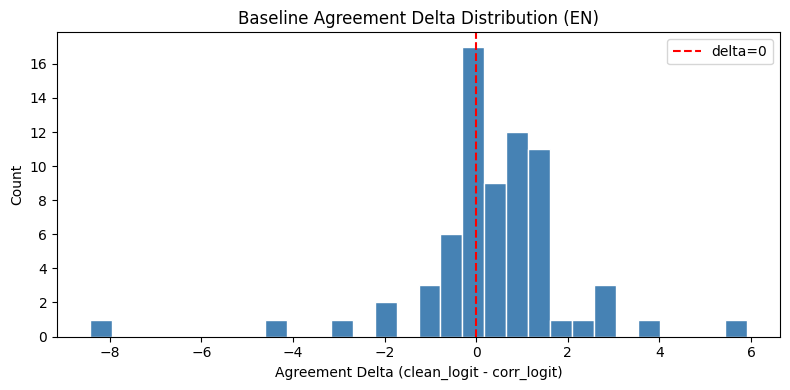


过滤后有效样本 (delta > 0): 70 条
Mean delta (filtered): 0.3325

--- Clean Logit 分层 ---
  clean_logit > -5:  59 条 | Mean delta = 0.7135
  clean_logit > -3:  58 条 | Mean delta = 0.7074
  clean_logit > -2:  58 条 | Mean delta = 0.7074
  clean_logit > -1:  55 条 | Mean delta = 0.7481
  clean_logit >  0:  52 条 | Mean delta = 0.7577


In [ ]:
# =============================================
# Cell 4: Baseline 评估
# 计算 clean/corr baseline，过滤有效样本
# =============================================

print("📊 计算 baseline agreement delta...")

results_baseline = []
for item in dataset:
    clean_logit, corr_logit, delta = get_agreement_delta(
        model, tokenizer, item, device, lang="de"
    )
    results_baseline.append({
        "item":        item,
        "clean_logit": clean_logit,
        "corr_logit":  corr_logit,
        "delta":       delta,
    })

valid = [r for r in results_baseline if r["delta"] is not None]
deltas = [r["delta"] for r in valid]

print(f"\n总样本: {len(dataset)} | 有效样本(index解析成功): {len(valid)}")
print(f"\n--- Baseline Agreement Delta ---")
print(f"Mean clean logit : {np.mean([r['clean_logit'] for r in valid]):.4f}")
print(f"Mean corr  logit : {np.mean([r['corr_logit']  for r in valid]):.4f}")
print(f"Mean delta       : {np.mean(deltas):.4f}")
print(f"delta > 0 比例   : {np.mean([d > 0 for d in deltas]):.2%}")

# 分布图
plt.figure(figsize=(8, 4))
plt.hist(deltas, bins=30, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", label="delta=0")
plt.xlabel("Agreement Delta (clean_logit - corr_logit)")
plt.ylabel("Count")
plt.title("Baseline Agreement Delta Distribution (DE)")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_delta_de.png", dpi=150)
plt.show()

# ── 过滤策略：只保留 delta > 0 的样本 ──
# 理由：delta <= 0 说明模型在该样本上方向已经错误，
#       这类样本会给 patching/ablation 引入噪声
# filtered        = [r for r in valid if r["delta"] > 0]
filtered        = [r for r in valid]
filtered_dataset = [r["item"] for r in filtered]

print(f"\n过滤后有效样本 (delta > 0): {len(filtered_dataset)} 条")
print(f"Mean delta (filtered): {np.mean([r['delta'] for r in filtered]):.4f}")

# clean logit 分层分析
print("\n--- Clean Logit 分层 ---")
for t in [-5, -3, -2, -1, 0]:
    sub = [r for r in filtered if r["clean_logit"] > t]
    if sub:
        print(f"  clean_logit > {t:2d}: {len(sub):3d} 条 | "
              f"Mean delta = {np.mean([r['delta'] for r in sub]):.4f}")

In [7]:
# =============================================
# Cell 5: 预计算激活与基准值
# =============================================

print("📦 预计算 filtered 数据集的激活与基准值...")

all_clean_acts  = []
all_corr_inputs = []
all_base_deltas = []   # corr 句下的 arc logit（patching 的起点）

for r in filtered:
    item = r["item"]

    # clean 激活（attention.self 输出）
    c_inp = tokenizer(item["de_clean"], return_tensors="pt").to(device)
    all_clean_acts.append(get_activations(model, c_inp))

    # corr inputs
    r_inp = tokenizer(item["de_corr"], return_tensors="pt").to(device)
    all_corr_inputs.append(r_inp)

    # baseline: corr 句本身的 arc logit（patching 目标：把这个拉高）
    all_base_deltas.append(r["corr_logit"])

print(f"✅ 预计算完成，共 {len(filtered_dataset)} 条")
print(f"Base corr logit mean: {np.mean(all_base_deltas):.4f}")

📦 预计算 filtered 数据集的激活与基准值...


✅ 预计算完成，共 70 条
Base corr logit mean: -1.6724


In [8]:
# =============================================
# Cell 6: Activation Patching — 逐 Head 扫描
# Metric: patching 后 corr_logit 相对 baseline 的提升
# Hook 位置: attention.self（pre-projection）
# =============================================

print(f"🚀 开始 Activation Patching ({n_layers}x{n_heads} heads)...")

logit_boost_heatmap = np.zeros((n_layers, n_heads))

for l in range(n_layers):
    for h in range(n_heads):
        total_boost = 0.0

        for i, (r, item) in enumerate(zip(filtered, filtered_dataset)):
            clean_acts  = all_clean_acts[i]
            corr_inputs = all_corr_inputs[i]
            base_logit  = all_base_deltas[i]
            corr_text   = item["de_corr"]
            tok         = item["_tok"]

            def patch_hook(module, input, output,
                           _l=l, _h=h, _acts=clean_acts):
                hidden = output[0] if isinstance(output, tuple) else output
                B, T_corr, D = hidden.shape
                clean_hidden = _acts[f"layer_{_l}"]
                _, T_clean, _ = clean_hidden.shape
                out_h = hidden.reshape(B, T_corr, n_heads, head_dim).clone()
                c_h   = clean_hidden.reshape(1, T_clean, n_heads, head_dim)
                min_T = min(T_corr, T_clean)
                out_h[:, :min_T, _h, :] = c_h[:, :min_T, _h, :]
                new_out = out_h.reshape(B, T_corr, D)
                return (new_out,) + output[1:] if isinstance(output, tuple) else new_out

            handle = model.encoder.encoder.layer[l].attention.self \
                         .register_forward_hook(patch_hook)
            try:
                with torch.no_grad():
                    out = model(**corr_inputs)
                    arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
                arc = apply_first_subword_mask(arc, tokenizer, corr_text, device)
                patched_logit = get_arc_logit(arc, tok["subj_tok_corr"], tok["verb_tok_corr"])
                if patched_logit is not None:
                    total_boost += (patched_logit - base_logit)
            finally:
                handle.remove()

        logit_boost_heatmap[l, h] = total_boost / len(filtered_dataset)

    print(f"  Layer {l:2d} 完成 | Max Logit Boost: {np.max(logit_boost_heatmap[l]):+.4f}")

print("\n✅ Patching 扫描完成")

🚀 开始 Activation Patching (12x12 heads)...


  Layer  0 完成 | Max Logit Boost: +0.0138
  Layer  1 完成 | Max Logit Boost: +0.0354
  Layer  2 完成 | Max Logit Boost: +0.0637
  Layer  3 完成 | Max Logit Boost: +0.0955
  Layer  4 完成 | Max Logit Boost: +0.0830
  Layer  5 完成 | Max Logit Boost: +0.2424
  Layer  6 完成 | Max Logit Boost: +0.1707
  Layer  7 完成 | Max Logit Boost: +0.0759
  Layer  8 完成 | Max Logit Boost: +0.1535
  Layer  9 完成 | Max Logit Boost: +0.1075
  Layer 10 完成 | Max Logit Boost: -0.0001
  Layer 11 完成 | Max Logit Boost: +0.0933

✅ Patching 扫描完成


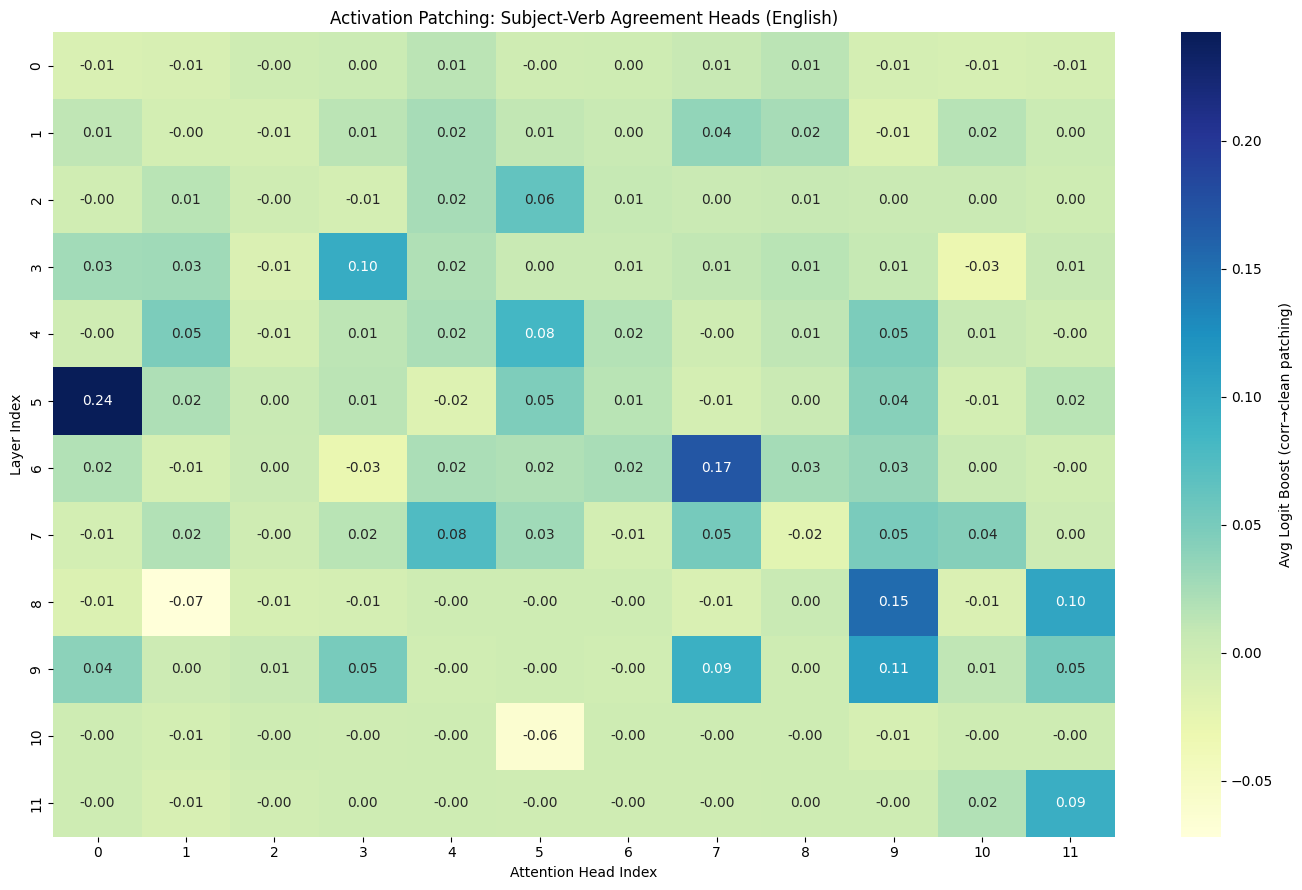

Top-20 Candidate Heads (Patching / Sufficiency):
-------------------------------------------------------
  Rank  1: Layer  5, Head  0 | Avg Boost: +0.2424
  Rank  2: Layer  6, Head  7 | Avg Boost: +0.1707
  Rank  3: Layer  8, Head  9 | Avg Boost: +0.1535
  Rank  4: Layer  9, Head  9 | Avg Boost: +0.1075
  Rank  5: Layer  8, Head 11 | Avg Boost: +0.1033
  Rank  6: Layer  3, Head  3 | Avg Boost: +0.0955
  Rank  7: Layer 11, Head 11 | Avg Boost: +0.0933
  Rank  8: Layer  9, Head  7 | Avg Boost: +0.0917
  Rank  9: Layer  4, Head  5 | Avg Boost: +0.0830
  Rank 10: Layer  7, Head  4 | Avg Boost: +0.0759
  Rank 11: Layer  2, Head  5 | Avg Boost: +0.0637
  Rank 12: Layer  9, Head 11 | Avg Boost: +0.0511
  Rank 13: Layer  7, Head  7 | Avg Boost: +0.0510
  Rank 14: Layer  9, Head  3 | Avg Boost: +0.0505
  Rank 15: Layer  7, Head  9 | Avg Boost: +0.0487
  Rank 16: Layer  4, Head  9 | Avg Boost: +0.0476
  Rank 17: Layer  4, Head  1 | Avg Boost: +0.0475
  Rank 18: Layer  5, Head  5 | Avg Boost: +0.

In [ ]:
# =============================================
# Cell 7: Patching 热力图 + Top-K Head 识别
# =============================================

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    logit_boost_heatmap, annot=True, fmt=".2f",
    cmap="YlGnBu", ax=ax,
    cbar_kws={"label": "Avg Logit Boost (corr→clean patching)"}
)
ax.set_title("Activation Patching: Subject-Verb Agreement Heads (English)")
ax.set_xlabel("Attention Head Index")
ax.set_ylabel("Layer Index")
plt.tight_layout()
plt.savefig("patching_heatmap_de.png", dpi=150)
plt.show()

TOP_K = 20
flat_idx = np.argsort(logit_boost_heatmap.flatten())[::-1]
candidate_heads = [(int(i // n_heads), int(i % n_heads)) for i in flat_idx[:TOP_K]]

print(f"Top-{TOP_K} Candidate Heads (Patching / Sufficiency):")
print("-" * 55)
for rank, (l, h) in enumerate(candidate_heads):
    boost = logit_boost_heatmap[l, h]
    print(f"  Rank {rank+1:2d}: Layer {l:2d}, Head {h:2d} | Avg Boost: {boost:+.4f}")
print("-" * 55)

In [10]:
# =============================================
# Cell 8: Mean Ablation — 预计算 attention.self 均值激活
# ★ 修复：均值在 attention.self 输出空间按 head 维度计算
#         与 patching hook 位置完全一致
# =============================================

print("📦 预计算 mean activations (attention.self, per-head)...")

# 收集所有样本在每层 attention.self 的输出
# shape per item: [1, seq, n_heads * head_dim]
layer_acts_collection = {l: [] for l in range(n_layers)}

for item in filtered_dataset:
    inp  = tokenizer(item["de_clean"], return_tensors="pt").to(device)
    acts = get_activations(model, inp)  # attention.self 输出
    for l in range(n_layers):
        layer_acts_collection[l].append(acts[f"layer_{l}"])  # [1, seq, D]

# 对每个 layer：先对每句话在 seq 维度取均值，再对所有句子取均值
# mean_acts[l] shape: [n_heads, head_dim]
mean_acts = {}
for l in range(n_layers):
    # 每句话 mean over seq → [1, D]，然后 cat → [N, D]，再 mean over N → [D]
    per_sentence_means = [a.mean(dim=1) for a in layer_acts_collection[l]]
    mean_vec = torch.cat(per_sentence_means, dim=0).mean(dim=0)  # [D]
    # reshape 到 [n_heads, head_dim]，方便按 head 索引
    mean_acts[l] = mean_vec.reshape(n_heads, head_dim)

print(f"✅ Mean activations 预计算完成，shape 示例: {mean_acts[0].shape}")
print(f"   (n_heads={n_heads}, head_dim={head_dim})")

# 预计算 clean baseline logits
all_clean_logits_f = [r["clean_logit"] for r in filtered]
print(f"Clean baseline mean logit: {np.mean(all_clean_logits_f):.4f}")

📦 预计算 mean activations (attention.self, per-head)...
✅ Mean activations 预计算完成，shape 示例: torch.Size([12, 64])
   (n_heads=12, head_dim=64)
Clean baseline mean logit: -1.3399


In [11]:
# =============================================
# Cell 9: Mean Ablation 扫描
# ★ 修复：hook 在 attention.self，head 维度切片直接有意义
# =============================================

print(f"\n🚀 开始 Mean Ablation 扫描 ({n_layers}x{n_heads} heads)...")

ablation_heatmap = np.zeros((n_layers, n_heads))

for l in range(n_layers):
    for h in range(n_heads):
        total_drop = 0.0

        for i, (r, item) in enumerate(zip(filtered, filtered_dataset)):
            clean_text = item["de_clean"]
            clean_inp  = tokenizer(clean_text, return_tensors="pt").to(device)
            base_logit = all_clean_logits_f[i]
            tok        = item["_tok"]

            # ★ mean_val 是在 attention.self 输出空间、head h 的均值向量
            mean_val = mean_acts[l][h]  # shape: [head_dim]

            def mean_ablation_hook(module, input, output,
                                   _h=h, _mean=mean_val):
                hidden = output[0] if isinstance(output, tuple) else output
                B, T, D = hidden.shape
                out_h = hidden.reshape(B, T, n_heads, head_dim).clone()
                # 将 head h 的所有位置替换为均值
                out_h[:, :, _h, :] = _mean
                new_out = out_h.reshape(B, T, D)
                return (new_out,) + output[1:] if isinstance(output, tuple) else new_out

            # ★ hook 挂在 attention.self，与 patching 一致
            handle = model.encoder.encoder.layer[l].attention.self \
                         .register_forward_hook(mean_ablation_hook)
            try:
                with torch.no_grad():
                    out = model(**clean_inp)
                    arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
                arc = apply_first_subword_mask(arc, tokenizer, clean_text, device)
                abl_logit = get_arc_logit(arc, tok["subj_tok_clean"], tok["verb_tok_clean"])
                if abl_logit is not None:
                    total_drop += (base_logit - abl_logit)
            finally:
                handle.remove()

        ablation_heatmap[l, h] = total_drop / len(filtered_dataset)

    print(f"  Layer {l:2d} 完成 | Max Logit Drop: {np.max(ablation_heatmap[l]):.4f}")

print("\n✅ Mean Ablation 扫描完成")


🚀 开始 Mean Ablation 扫描 (12x12 heads)...


  Layer  0 完成 | Max Logit Drop: 0.0532
  Layer  1 完成 | Max Logit Drop: 0.0934
  Layer  2 完成 | Max Logit Drop: 0.0123
  Layer  3 完成 | Max Logit Drop: 0.0251
  Layer  4 完成 | Max Logit Drop: 0.0809
  Layer  5 完成 | Max Logit Drop: 0.2145
  Layer  6 完成 | Max Logit Drop: 0.3377
  Layer  7 完成 | Max Logit Drop: 0.1052
  Layer  8 完成 | Max Logit Drop: 0.7091
  Layer  9 完成 | Max Logit Drop: 0.6086
  Layer 10 完成 | Max Logit Drop: 0.2546
  Layer 11 完成 | Max Logit Drop: 0.2687

✅ Mean Ablation 扫描完成


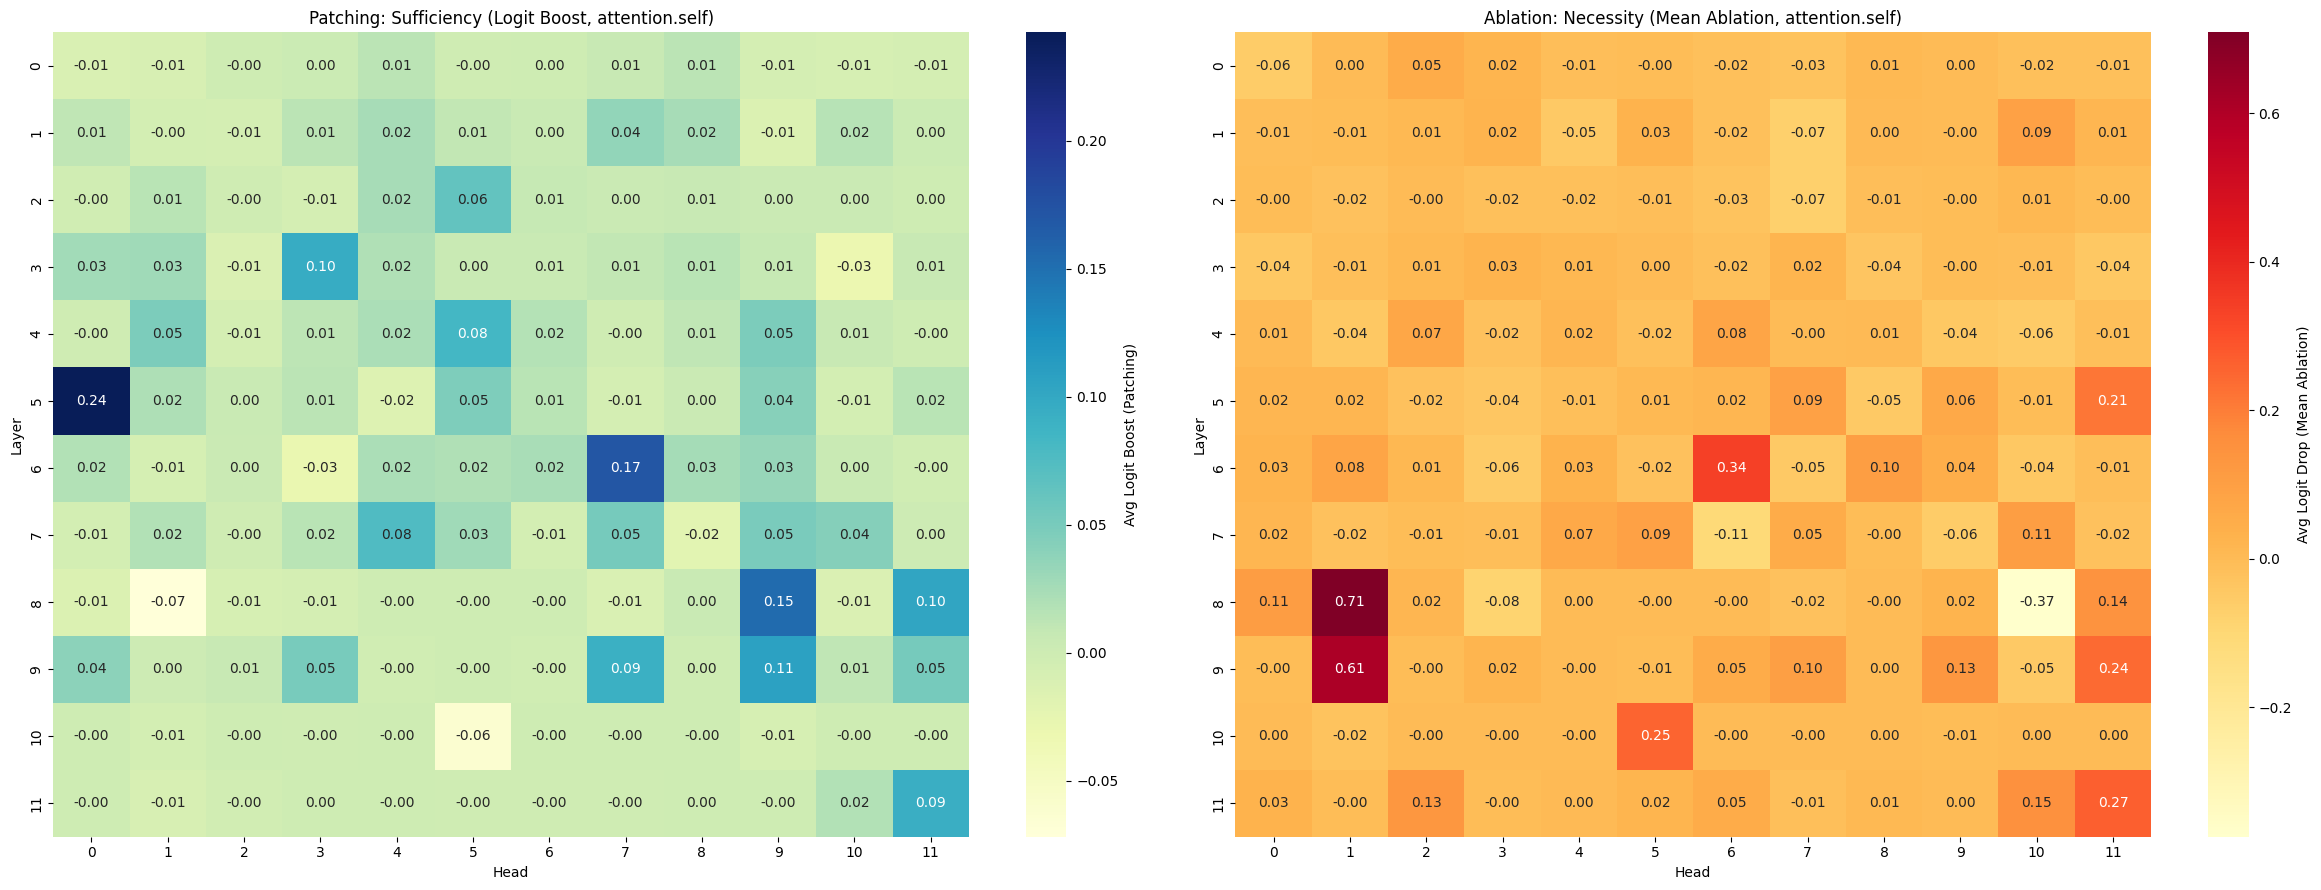


Top-20 Essential Heads (Mean Ablation, attention.self):
-------------------------------------------------------
  Rank  1: Layer  8, Head  1 | Avg Drop: 0.7091
  Rank  2: Layer  9, Head  1 | Avg Drop: 0.6086
  Rank  3: Layer  6, Head  6 | Avg Drop: 0.3377
  Rank  4: Layer 11, Head 11 | Avg Drop: 0.2687
  Rank  5: Layer 10, Head  5 | Avg Drop: 0.2546
  Rank  6: Layer  9, Head 11 | Avg Drop: 0.2412
  Rank  7: Layer  5, Head 11 | Avg Drop: 0.2145
  Rank  8: Layer 11, Head 10 | Avg Drop: 0.1543
  Rank  9: Layer  8, Head 11 | Avg Drop: 0.1445
  Rank 10: Layer  9, Head  9 | Avg Drop: 0.1326
  Rank 11: Layer 11, Head  2 | Avg Drop: 0.1310
  Rank 12: Layer  8, Head  0 | Avg Drop: 0.1089
  Rank 13: Layer  7, Head 10 | Avg Drop: 0.1052
  Rank 14: Layer  6, Head  8 | Avg Drop: 0.1038
  Rank 15: Layer  9, Head  7 | Avg Drop: 0.1008
  Rank 16: Layer  7, Head  5 | Avg Drop: 0.0944
  Rank 17: Layer  1, Head 10 | Avg Drop: 0.0934
  Rank 18: Layer  5, Head  7 | Avg Drop: 0.0929
  Rank 19: Layer  4, He

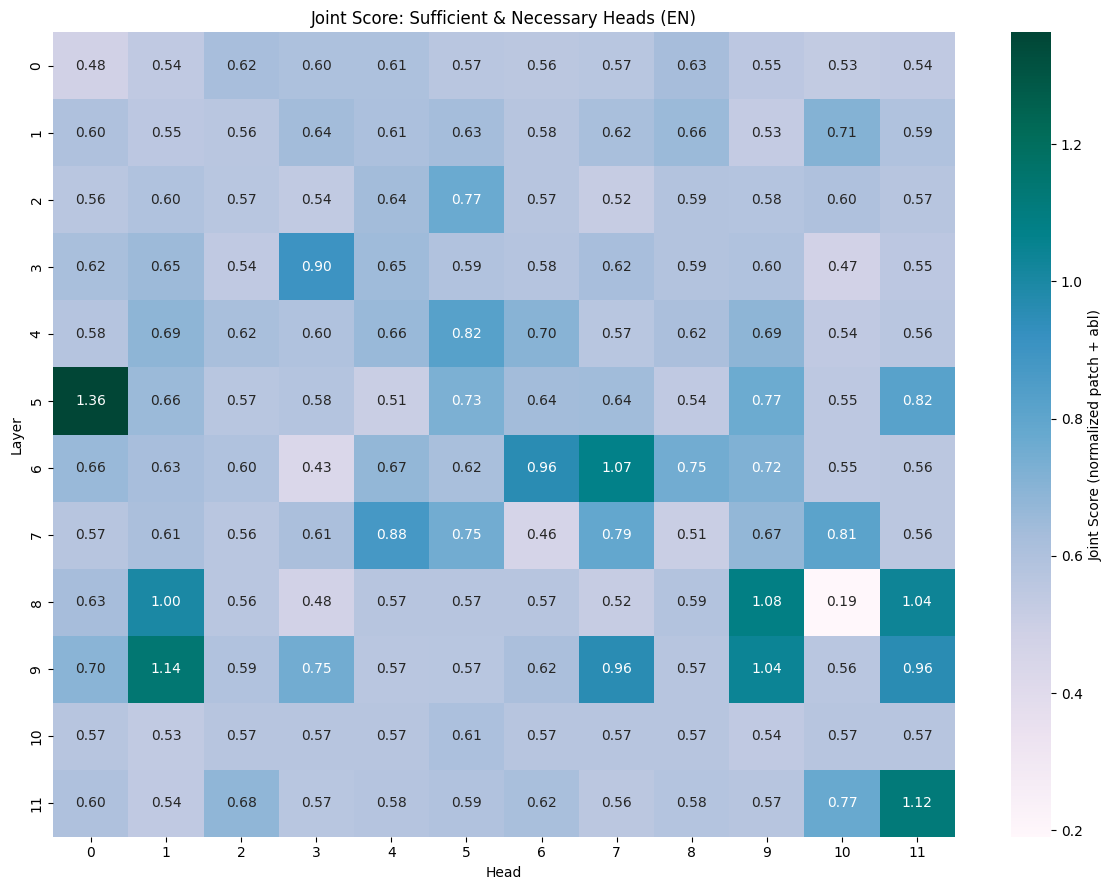

In [ ]:
# =============================================
# Cell 10: Ablation 热力图 + Joint Score
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

sns.heatmap(logit_boost_heatmap, annot=True, fmt=".2f", cmap="YlGnBu",
            ax=axes[0], cbar_kws={"label": "Avg Logit Boost (Patching)"})
axes[0].set_title("Patching: Sufficiency (Logit Boost, attention.self)")
axes[0].set_xlabel("Head"); axes[0].set_ylabel("Layer")

sns.heatmap(ablation_heatmap, annot=True, fmt=".2f", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "Avg Logit Drop (Mean Ablation)"})
axes[1].set_title("Ablation: Necessity (Mean Ablation, attention.self)")
axes[1].set_xlabel("Head"); axes[1].set_ylabel("Layer")

plt.tight_layout()
plt.savefig("patching_ablation_comparison_de.png", dpi=150)
plt.show()

# ── Top-K Essential Heads ──
flat_abl = np.argsort(ablation_heatmap.flatten())[::-1]
essential_heads = [(int(i // n_heads), int(i % n_heads)) for i in flat_abl[:TOP_K]]

print(f"\nTop-{TOP_K} Essential Heads (Mean Ablation, attention.self):")
print("-" * 55)
for rank, (l, h) in enumerate(essential_heads):
    drop = ablation_heatmap[l, h]
    print(f"  Rank {rank+1:2d}: Layer {l:2d}, Head {h:2d} | Avg Drop: {drop:.4f}")
print("-" * 55)

# ── Overlap ──
overlap = set(candidate_heads) & set(essential_heads)
print(f"\n🎯 Patching + Ablation 双重确认的 Head: {sorted(overlap)}")

# ── Joint Score（归一化后相加）──
patch_norm = (logit_boost_heatmap - logit_boost_heatmap.min()) / \
             (logit_boost_heatmap.max() - logit_boost_heatmap.min() + 1e-8)
abl_norm   = (ablation_heatmap - ablation_heatmap.min()) / \
             (ablation_heatmap.max() - ablation_heatmap.min() + 1e-8)
joint_score = patch_norm + abl_norm

flat_joint = np.argsort(joint_score.flatten())[::-1]
joint_top  = [(int(i // n_heads), int(i % n_heads)) for i in flat_joint[:TOP_K]]

print(f"\nJoint Top-{TOP_K} (Sufficient + Necessary):")
print("-" * 70)
for rank, (l, h) in enumerate(joint_top[:20]):
    print(f"  {rank+1:2d}. L{l:2d}H{h:2d} | "
          f"patch={logit_boost_heatmap[l,h]:+.4f} | "
          f"abl={ablation_heatmap[l,h]:.4f} | "
          f"joint={joint_score[l,h]:.4f}")

plt.figure(figsize=(12, 9))
sns.heatmap(joint_score, annot=True, fmt=".2f", cmap="PuBuGn",
            cbar_kws={"label": "Joint Score (normalized patch + abl)"})
plt.title("Joint Score: Sufficient & Necessary Heads (DE)")
plt.xlabel("Head"); plt.ylabel("Layer")
plt.tight_layout()
plt.savefig("joint_score_de.png", dpi=150)
plt.show()

In [13]:
# =============================================
# Cell 11: 组合回路搜索
# 在 Top-K candidate heads 中枚举子集，找最优 circuit
# =============================================

MAX_SIZE  = 6
POOL_SIZE = 10

# 优先使用 overlap（sufficient AND necessary），不足则用 joint top-k
pool = sorted(overlap) if len(overlap) >= 3 else joint_top[:POOL_SIZE]
print(f"🎯 候选池 ({len(pool)} 个): {pool}")

combination_results = []

for r_size in range(1, MAX_SIZE + 1):
    sub_circuits = list(itertools.combinations(pool, r_size))
    print(f"  评估大小={r_size} 的组合 ({len(sub_circuits)} 种)...")

    for circuit in sub_circuits:
        layer2heads = {}
        for l, h in circuit:
            layer2heads.setdefault(l, []).append(h)

        total_boost = 0.0

        for i, (r, item) in enumerate(zip(filtered, filtered_dataset)):
            clean_acts  = all_clean_acts[i]
            corr_inputs = all_corr_inputs[i]
            base_logit  = all_base_deltas[i]
            corr_text   = item["de_corr"]
            tok         = item["_tok"]

            def make_patch_hook(l_idx, h_list, _acts=clean_acts):
                def hook(module, input, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    B, T_c, D = hidden.shape
                    clean_h = _acts[f"layer_{l_idx}"]
                    _, T_k, _ = clean_h.shape
                    out_h = hidden.reshape(B, T_c, n_heads, head_dim).clone()
                    c_h   = clean_h.reshape(1, T_k, n_heads, head_dim)
                    min_T = min(T_c, T_k)
                    for hh in h_list:
                        out_h[:, :min_T, hh, :] = c_h[:, :min_T, hh, :]
                    new_out = out_h.reshape(B, T_c, D)
                    return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
                return hook

            handles = [
                model.encoder.encoder.layer[l_idx].attention.self
                    .register_forward_hook(make_patch_hook(l_idx, h_list))
                for l_idx, h_list in layer2heads.items()
            ]
            try:
                with torch.no_grad():
                    out = model(**corr_inputs)
                    arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
                arc = apply_first_subword_mask(arc, tokenizer, corr_text, device)
                pl  = get_arc_logit(arc, tok["subj_tok_corr"], tok["verb_tok_corr"])
                if pl is not None:
                    total_boost += (pl - base_logit)
            finally:
                for hh in handles:
                    hh.remove()

        combination_results.append({
            "circuit":   circuit,
            "size":      r_size,
            "avg_boost": total_boost / len(filtered_dataset),
        })

combination_results.sort(key=lambda x: x["avg_boost"], reverse=True)

print("\n" + "=" * 60)
print("🏆 Top-10 Sub-Circuits (by Avg Logit Boost)")
print("=" * 60)
for i, res in enumerate(combination_results[:10]):
    print(f"  Rank {i+1} [Size {res['size']}]: {res['circuit']} | "
          f"Boost: {res['avg_boost']:+.4f}")

🎯 候选池 (6 个): [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]
  评估大小=1 的组合 (6 种)...


  评估大小=2 的组合 (15 种)...
  评估大小=3 的组合 (20 种)...
  评估大小=4 的组合 (15 种)...
  评估大小=5 的组合 (6 种)...
  评估大小=6 的组合 (1 种)...

🏆 Top-10 Sub-Circuits (by Avg Logit Boost)
  Rank 1 [Size 6]: ((7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)) | Boost: +0.3558
  Rank 2 [Size 5]: ((7, 10), (8, 11), (9, 7), (9, 9), (11, 11)) | Boost: +0.3498
  Rank 3 [Size 5]: ((8, 11), (9, 7), (9, 9), (9, 11), (11, 11)) | Boost: +0.3365
  Rank 4 [Size 4]: ((8, 11), (9, 7), (9, 9), (11, 11)) | Boost: +0.3280
  Rank 5 [Size 5]: ((7, 10), (9, 7), (9, 9), (9, 11), (11, 11)) | Boost: +0.3073
  Rank 6 [Size 5]: ((7, 10), (8, 11), (9, 9), (9, 11), (11, 11)) | Boost: +0.3034
  Rank 7 [Size 5]: ((7, 10), (8, 11), (9, 7), (9, 9), (9, 11)) | Boost: +0.3008
  Rank 8 [Size 4]: ((7, 10), (9, 7), (9, 9), (11, 11)) | Boost: +0.2961
  Rank 9 [Size 4]: ((7, 10), (8, 11), (9, 9), (11, 11)) | Boost: +0.2956
  Rank 10 [Size 4]: ((9, 7), (9, 9), (9, 11), (11, 11)) | Boost: +0.2892


In [14]:
# =============================================
# Cell 12: 最优回路的必要性验证（Circuit Ablation）
# ★ 统一：ablation hook 在 attention.self
# =============================================

def make_abl_hook(h_list, layer_idx):
    """在 attention.self 输出空间，将指定 heads 替换为均值"""
    # mean_acts[layer_idx] shape: [n_heads, head_dim]
    mean_val_layer = mean_acts[layer_idx]

    def hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        B, T, D = hidden.shape
        out_h = hidden.reshape(B, T, n_heads, head_dim).clone()
        for hh in h_list:
            out_h[:, :, hh, :] = mean_val_layer[hh]  # [head_dim]
        new_out = out_h.reshape(B, T, D)
        return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
    return hook


def evaluate_ablation(circuit, name=""):
    """
    对 circuit 做 mean ablation，在 clean 句上评估 logit drop。
    drop_pct = (clean_logit - ablated_logit) / |agreement_delta| * 100
    """
    layer2heads = {}
    for l, h in circuit:
        layer2heads.setdefault(l, []).append(h)

    total_clean   = 0.0
    total_corr    = 0.0
    total_ablated = 0.0

    for r, item in zip(filtered, filtered_dataset):
        clean_text = item["de_clean"]
        clean_inp  = tokenizer(clean_text, return_tensors="pt").to(device)
        tok        = item["_tok"]

        total_clean += r["clean_logit"]
        total_corr  += r["corr_logit"]

        # hook 挂在 attention.self
        handles = [
            model.encoder.encoder.layer[l_idx].attention.self
                .register_forward_hook(make_abl_hook(h_list, l_idx))
            for l_idx, h_list in layer2heads.items()
        ]
        try:
            with torch.no_grad():
                out = model(**clean_inp)
                arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
            arc = apply_first_subword_mask(arc, tokenizer, clean_text, device)
            abl_logit = get_arc_logit(arc, tok["subj_tok_clean"], tok["verb_tok_clean"])
            if abl_logit is not None:
                total_ablated += abl_logit
        finally:
            for hh in handles:
                hh.remove()

    n = len(filtered_dataset)
    avg_clean   = total_clean   / n
    avg_corr    = total_corr    / n
    avg_ablated = total_ablated / n
    avg_delta   = avg_clean - avg_corr
    drop        = avg_clean - avg_ablated
    drop_pct    = drop / abs(avg_delta) * 100 if avg_delta != 0 else 0.0

    print("\n" + "=" * 60)
    print(f"📊 Ablation Result: {name}")
    print("=" * 60)
    print(f"  Clean logit    : {avg_clean:.4f}")
    print(f"  Corr  logit    : {avg_corr:.4f}")
    print(f"  Baseline delta : {avg_delta:.4f}")
    print(f"  Ablated logit  : {avg_ablated:.4f}")
    print(f"  Logit drop     : {drop:.4f}")
    print(f"  相对下降(÷Δ)  : {drop_pct:.2f}%")

    return {"name": name, "drop": drop, "drop_pct": drop_pct}


# ================================
# 1. Best Circuit Ablation
# ================================
best_circuit = combination_results[0]["circuit"]
print(f"\n🚀 Best Circuit: {best_circuit}")
res_best = evaluate_ablation(best_circuit, name="Best Circuit")

# ================================
# 2. Top-K Heads Ablation（整个候选池）
# ================================
print(f"\n🔥 Top-{len(pool)} Heads (整个候选池): {pool}")
res_topk = evaluate_ablation(pool, name=f"Top-{len(pool)} Heads (Pool)")

# ================================
# 3. Leave-One-Out 分析
# ================================
print("\n🧠 Leave-One-Out Analysis")
loo_results = []
for i in range(len(best_circuit)):
    sub_circuit = [h for j, h in enumerate(best_circuit) if j != i]
    removed = best_circuit[i]
    res = evaluate_ablation(sub_circuit, name=f"Remove {removed}")
    loo_results.append((removed, res["drop_pct"]))

print("\n" + "=" * 60)
print("🏆 Critical Heads (Leave-One-Out，按重要性排序)")
print("=" * 60)
loo_results.sort(key=lambda x: x[1], reverse=True)
for i, (head, drop_pct) in enumerate(loo_results):
    print(f"  Rank {i+1}: Remove {head} → Remaining Drop {drop_pct:.2f}%")

# ================================
# 4. Top-N Circuits Comparison
# ================================
print("\n🔬 Top-N Circuits Comparison")
topN = 5
multi_results = []
for i in range(min(topN, len(combination_results))):
    circuit = combination_results[i]["circuit"]
    print(f"\n🚀 Evaluating Top-{i+1} Circuit: {circuit}")
    res = evaluate_ablation(circuit, name=f"Top-{i+1} Circuit")
    multi_results.append((i + 1, res["drop_pct"]))

print("\n" + "=" * 60)
print("📊 Multi-Circuit Comparison")
print("=" * 60)
for rank, drop_pct in multi_results:
    print(f"  Rank {rank}: Drop {drop_pct:.2f}%")


🚀 Best Circuit: ((7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11))



📊 Ablation Result: Best Circuit
  Clean logit    : -1.3399
  Corr  logit    : -1.6724
  Baseline delta : 0.3325
  Ablated logit  : -2.4441
  Logit drop     : 1.1043
  相对下降(÷Δ)  : 332.13%

🔥 Top-6 Heads (整个候选池): [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]

📊 Ablation Result: Top-6 Heads (Pool)
  Clean logit    : -1.3399
  Corr  logit    : -1.6724
  Baseline delta : 0.3325
  Ablated logit  : -2.4441
  Logit drop     : 1.1043
  相对下降(÷Δ)  : 332.13%

🧠 Leave-One-Out Analysis

📊 Ablation Result: Remove (7, 10)
  Clean logit    : -1.3399
  Corr  logit    : -1.6724
  Baseline delta : 0.3325
  Ablated logit  : -2.3538
  Logit drop     : 1.0140
  相对下降(÷Δ)  : 304.97%

📊 Ablation Result: Remove (8, 11)
  Clean logit    : -1.3399
  Corr  logit    : -1.6724
  Baseline delta : 0.3325
  Ablated logit  : -2.3001
  Logit drop     : 0.9602
  相对下降(÷Δ)  : 288.81%

📊 Ablation Result: Remove (9, 7)
  Clean logit    : -1.3399
  Corr  logit    : -1.6724
  Baseline delta : 0.3325
  Ablated logit  : -

In [15]:
# =============================================
# Cell 13: 实验结论汇总
# =============================================

print("=" * 70)
print("📋 EN 单语言实验结论")
print("=" * 70)

print(f"\n📊 数据统计:")
print(f"  总样本: {len(dataset)} | index解析成功: {len(valid)} | "
      f"delta>0有效: {len(filtered)}")
print(f"  Mean agreement delta (filtered): "
      f"{np.mean([r['delta'] for r in filtered]):.4f}")

print(f"\n🎯 候选池 ({len(pool)} 个 heads):")
for l, h in pool:
    tag = "✅[sufficient+necessary]" if (l, h) in overlap else \
          "🔵[sufficient]" if (l, h) in set(candidate_heads) else \
          "🟡[necessary]"
    print(f"  L{l:2d}H{h:2d} {tag} | "
          f"patch={logit_boost_heatmap[l,h]:+.4f} | "
          f"abl={ablation_heatmap[l,h]:.4f}")

print(f"\n🏆 Best Circuit: {best_circuit}")
print(f"  Ablation Drop: {res_best['drop_pct']:.2f}%")

print(f"\n💡 Hook 位置: attention.self (pre-projection)")
print(f"   Patching 和 Ablation 使用相同 hook 位置，结论一致")

📋 EN 单语言实验结论

📊 数据统计:
  总样本: 70 | index解析成功: 70 | delta>0有效: 70
  Mean agreement delta (filtered): 0.3325

🎯 候选池 (6 个 heads):
  L 7H10 ✅[sufficient+necessary] | patch=+0.0434 | abl=0.1052
  L 8H11 ✅[sufficient+necessary] | patch=+0.1033 | abl=0.1445
  L 9H 7 ✅[sufficient+necessary] | patch=+0.0917 | abl=0.1008
  L 9H 9 ✅[sufficient+necessary] | patch=+0.1075 | abl=0.1326
  L 9H11 ✅[sufficient+necessary] | patch=+0.0511 | abl=0.2412
  L11H11 ✅[sufficient+necessary] | patch=+0.0933 | abl=0.2687

🏆 Best Circuit: ((7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11))
  Ablation Drop: 332.13%

💡 Hook 位置: attention.self (pre-projection)
   Patching 和 Ablation 使用相同 hook 位置，结论一致
